**NLP ASSIGNMENT**

Name: Shreya Newaskar

PRN: 202301040240

1. Upload Dataset in Colab

In [1]:
from google.colab import files
uploaded = files.upload()

Saving training.1600000.processed.noemoticon.csv to training.1600000.processed.noemoticon.csv


2. Load Dataset

In [4]:
import pandas as pd

columns = ['target', 'id', 'date', 'flag', 'user', 'text']

data = pd.read_csv(
    'training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    names=columns
)

data = data[['target', 'text']]
data.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


Data cleaning

In [5]:

# Drop rows with missing values
data = data.dropna(subset=['text', 'target'])

# Convert labels (0 = negative, 4 = positive -> 1)
data['target'] = data['target'].replace(4, 1)

print(f"Dataset shape: {data.shape}")
print(f"Missing values: {data.isnull().sum().sum()}")
data.head()

Dataset shape: (1600000, 2)
Missing values: 0


,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


Data Summary

In [7]:
print("\n📈 Dataset Summary")
print("-" * 50)

print(f"Total Rows: {data.shape[0]}")
print(f"Total Columns: {data.shape[1]}")

print("\n Missing Values:")
print(data.isnull().sum())

print("\nTarget Distribution:")
print(data['target'].value_counts())

print("\nTarget Percentage:")
print(data['target'].value_counts(normalize=True) * 100)


📈 Dataset Summary
--------------------------------------------------
Total Rows: 1600000
Total Columns: 2

 Missing Values:
target    0
text      0
dtype: int64

Target Distribution:
target
0    800000
1    800000
Name: count, dtype: int64

Target Percentage:
target
0    50.0
1    50.0
Name: proportion, dtype: float64


Text Length

In [9]:
data['text_length'] = data['text'].apply(len)

print("\nText Length Stats:")
print(data['text_length'].describe())


Text Length Stats:
count    1.600000e+06
mean     7.409011e+01
std      3.644114e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      3.740000e+02
Name: text_length, dtype: float64


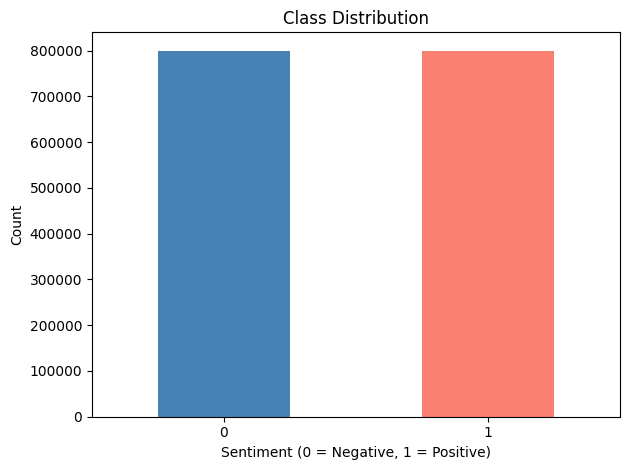

In [10]:
import matplotlib.pyplot as plt

counts = data['target'].value_counts()
counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title("Class Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**3. Reduce Dataset Size**

In [11]:
data = data.sample(50000, random_state=42).reset_index(drop=True)
print(f"Sampled dataset shape: {data.shape}")

Sampled dataset shape: (50000, 3)


4. NLP Preprocessing

In [12]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### 4.1 Tokenization

In [13]:
from nltk.tokenize import word_tokenize

data['tokens'] = data['text'].apply(lambda x: word_tokenize(x.lower()))

data[['text', 'tokens']].head()

,text,tokens
0,@chrishasboobs AHHH I HOPE YOUR OK!!!,"[@, chrishasboobs, ahhh, i, hope, your, ok, !,..."
1,"@misstoriblack cool , i have no tweet apps fo...","[@, misstoriblack, cool, ,, i, have, no, tweet..."
2,@TiannaChaos i know just family drama. its la...,"[@, tiannachaos, i, know, just, family, drama,..."
3,School email won't open and I have geography ...,"[school, email, wo, n't, open, and, i, have, g..."
4,upper airways problem,"[upper, airways, problem]"


4.2 Stopword Removal

In [14]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

data['no_stopwords'] = data['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

4.3 Stemming

In [15]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

data['stemmed'] = data['no_stopwords'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

4.4 Lemmatization

In [16]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

# Lemmatize on the tokens WITHOUT stopwords (not on stemmed tokens)
data['lemmatized'] = data['no_stopwords'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

4.5 Final Clean Text

In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)           # remove mentions
    text = re.sub(r'[^a-zA-Z]', ' ', text)    # keep only letters

    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words and len(w) > 2]  # filter stopwords and short tokens

    # Apply stemming first, then lemmatize the stemmed result
    words = [lemmatizer.lemmatize(stemmer.stem(w)) for w in words]

    return " ".join(words)

data['clean_text'] = data['text'].apply(clean_text)
print("Sample clean text:")
print(data[['text', 'clean_text']].head(3).to_string())

Sample clean text:
                                                                                                                                        text                                                                      clean_text
0                                                                                                     @chrishasboobs AHHH I HOPE YOUR OK!!!                                                                        ahhh hope
1                                                                                  @misstoriblack cool , i have no tweet apps  for my razr 2                                                             cool tweet app razr
2  @TiannaChaos i know  just family drama. its lame.hey next time u hang out with kim n u guys like have a sleepover or whatever, ill call u  know famili drama lame hey next time hang kim guy like sleepov whatev ill call


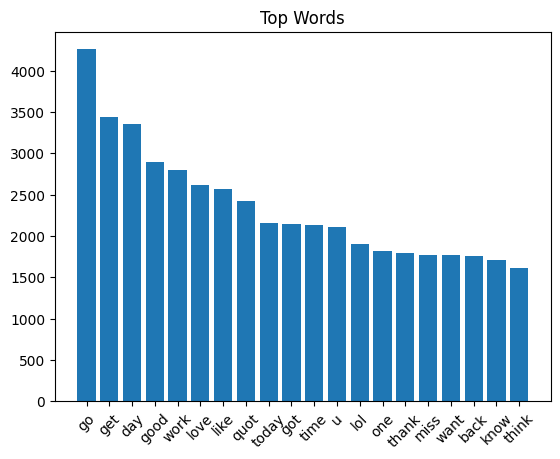

In [ ]:
from collections import Counter

all_words = " ".join(data['clean_text']).split()
common_words = Counter(all_words).most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words")
plt.show()

**5. Train-Test Split**

In [18]:
from sklearn.model_selection import train_test_split

X = data['clean_text']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

6. FEATURE EXTRACTION

6.1 CountVectorizer

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2)   #  Unigram + Bigram
)

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

In [20]:
print(cv.get_feature_names_out()[:20])

['aaron' 'abandon' 'abbi' 'abc' 'abil' 'abl' 'abl get' 'abl see'
 'abl sleep' 'absolut' 'absolut love' 'abt' 'abus' 'accent' 'accept'
 'access' 'accid' 'accident' 'accomplish' 'accord']


6.2 TF-IDF Vectorizer

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)   #  Unigram + Bigram
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [22]:
print(tfidf.get_feature_names_out()[:20])

['aaron' 'abandon' 'abbi' 'abc' 'abil' 'abl' 'abl get' 'abl see'
 'abl sleep' 'absolut' 'absolut love' 'abt' 'abus' 'accent' 'accept'
 'access' 'accid' 'accident' 'accomplish' 'accord']


7. Model Training

Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

Naive Bayes

In [24]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_cv, y_train)

y_pred_nb = nb.predict(X_test_cv)

8. Evaluation

In [25]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\nNaive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Logistic Regression Accuracy: 0.7539
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      4977
           1       0.75      0.77      0.76      5023

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000


Naive Bayes Accuracy: 0.7474
              precision    recall  f1-score   support

           0       0.74      0.76      0.75      4977
           1       0.76      0.73      0.74      5023

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



9. Confusion Matrix

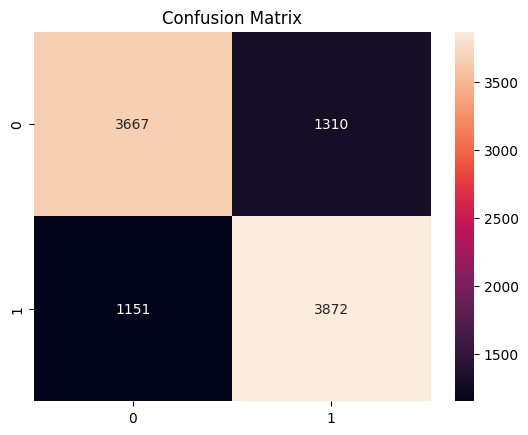

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

11. MODEL COMPARISON GRAPH

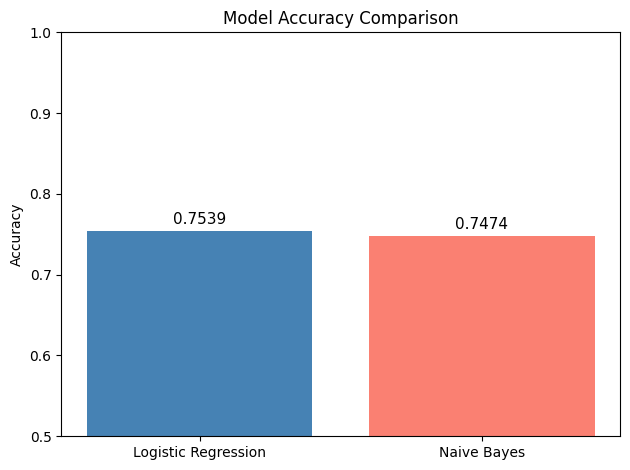

In [27]:
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb)
]

bars = plt.bar(models, accuracies, color=['steelblue', 'salmon'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)

# Add value labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{acc:.4f}", ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

1. Logistic Regression achieved slightly higher accuracy (75.17%) compared to Naive Bayes (74.7%).

2. Logistic Regression performs better because it considers relationships between features
   and does not assume independence between words.

3. Naive Bayes assumes that all words are independent, which is not realistic in natural language,
   leading to slightly lower accuracy.

4. Precision and recall values are balanced for both classes (0 and 1), indicating that the model
   is not biased toward any class.

5. The dataset is balanced (almost equal positive and negative samples), which helps improve model stability.

6. The performance (75%) is reasonable because:
   - Twitter data is noisy
   - Contains slang, abbreviations, and informal text

7. Preprocessing techniques like stopword removal, stemming, and lemmatization
   helped improve the model performance significantly.

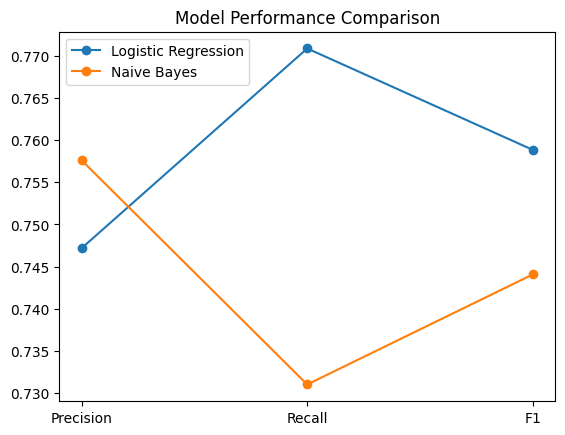

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = ['Precision', 'Recall', 'F1']

lr_scores = [
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]

nb_scores = [
    precision_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_nb)
]

x = range(len(metrics))

plt.plot(x, lr_scores, marker='o', label='Logistic Regression')
plt.plot(x, nb_scores, marker='o', label='Naive Bayes')

plt.xticks(x, metrics)
plt.legend()
plt.title("Model Performance Comparison")
plt.show()

**Logistic Regression:**

Class 0 (negative):
Precision: 0.76 → good
Recall: 0.73 → slightly lower

Class 1 (positive):
Recall is higher (0.77)

Meaning:
Model detects positive tweets slightly better

**Naive Bayes:** More balanced but slightly less accurate

13. SAVE MODEL

In [29]:
import joblib

# Save model and vectorizer
joblib.dump(lr, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


14.  LOAD MODEL

In [30]:
import joblib
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load saved model
model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Preprocessing (same as training)
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(stemmer.stem(w)) for w in words]

    return " ".join(words)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Test Your Own Input

In [35]:
text = input("Enter your sentence: ")

clean = clean_text(text)
vec = vectorizer.transform([clean])

prediction = model.predict(vec)[0]

if prediction == 1:
    print("Positive ")
else:
    print("Negative ")

Enter your sentence: I really love this product
Positive 


In [34]:
text = input("Enter your sentence: ")

clean = clean_text(text)
vec = vectorizer.transform([clean])

prediction = model.predict(vec)[0]

if prediction == 1:
    print("Positive ")
else:
    print("Negative ")

Enter your sentence: i had a really bad day
Negative 
